In [198]:
# load data
library(ggplot2)
data_all = read.table("/well/lindgren-ukbb/projects/ukbb-11867/ferreira/PCOS/locuszoom_plots/All_leads_stats_nowindow_2.txt", header=T)

# filter rows (duplicated and target traits)
data <- data_all[data_all$Trait %in% c("bmi", "whradjbmi", "Waist_circumference", "Hip_circumference", "Body_fat_percentage"),]
data <- data[!duplicated(data),]

# add stat params and 
data$Analysis <- factor(data$Analysis)
data$pheno = paste(data$Trait, "-", data$Analysis, sep="")
data$LCI = data$Beta_MinorAllele - 1.96 * data$SE
data$UCI = data$Beta_MinorAllele + 1.96 * data$SE

# add aesthetic params
data$shape = ifelse(data$P<=1e-5, "p<=1e-5", "p>1e5")
data$significance = factor(data$shape)
data$transparency = factor(ifelse(data$P<=1e-5, 1, 0.2))

# set colors
my_colors <- c('green3','red2','blue1')
names(my_colors) <- levels(data$Analysis)
color_scale <- scale_colour_manual(name = "Analysis",values = my_colors)

# get genes
genes <- unique(data_all$Gene)

for (g in genes){
    
    d <- data[data$Gene %in% g,]
    
    p2 <- ggplot(d, aes(
        x = Analysis, 
        y = Beta_MinorAllele, 
        ymin = LCI, 
        ymax = UCI, 
        shape= significance, 
        color = Analysis,
        alpha = transparency
        )
      )+
    geom_point(size = 3) + 
    geom_errorbar(width=0.1, cex=0.8)+ ### SE
    geom_hline(yintercept=0, linetype=2)+
    facet_wrap(~Trait,strip.position="left",ncol=2,scales = "free_y") +
    theme(plot.title=element_text(size=10,face="bold"),
            axis.text.y=element_blank(),
            axis.ticks.y=element_blank(),
            axis.text.x=element_text(face="bold", size=12),
            axis.title=element_text(size=14,face="bold"),
            strip.text.y = element_text(hjust=0,vjust = 1,face="bold",size=12))+
    coord_flip()+
    color_scale + 
    xlab('')+ ylab("Beta (SE)") +
    scale_alpha_manual(values=c(0.1,1)) +
    guides(col = guide_legend(reverse = TRUE), alpha = "none") +
    theme(legend.text=element_text(size=12),legend.title=element_text(size=12,face="bold"))
    
    outfile = paste("/well/lindgren-ukbb/projects/ukbb-11867/ferreira/PCOS/ANGPTLs/", g, "_forest_plots_1.png", sep="")
    ggsave(outfile, p2, width = 12, height = 8)
}


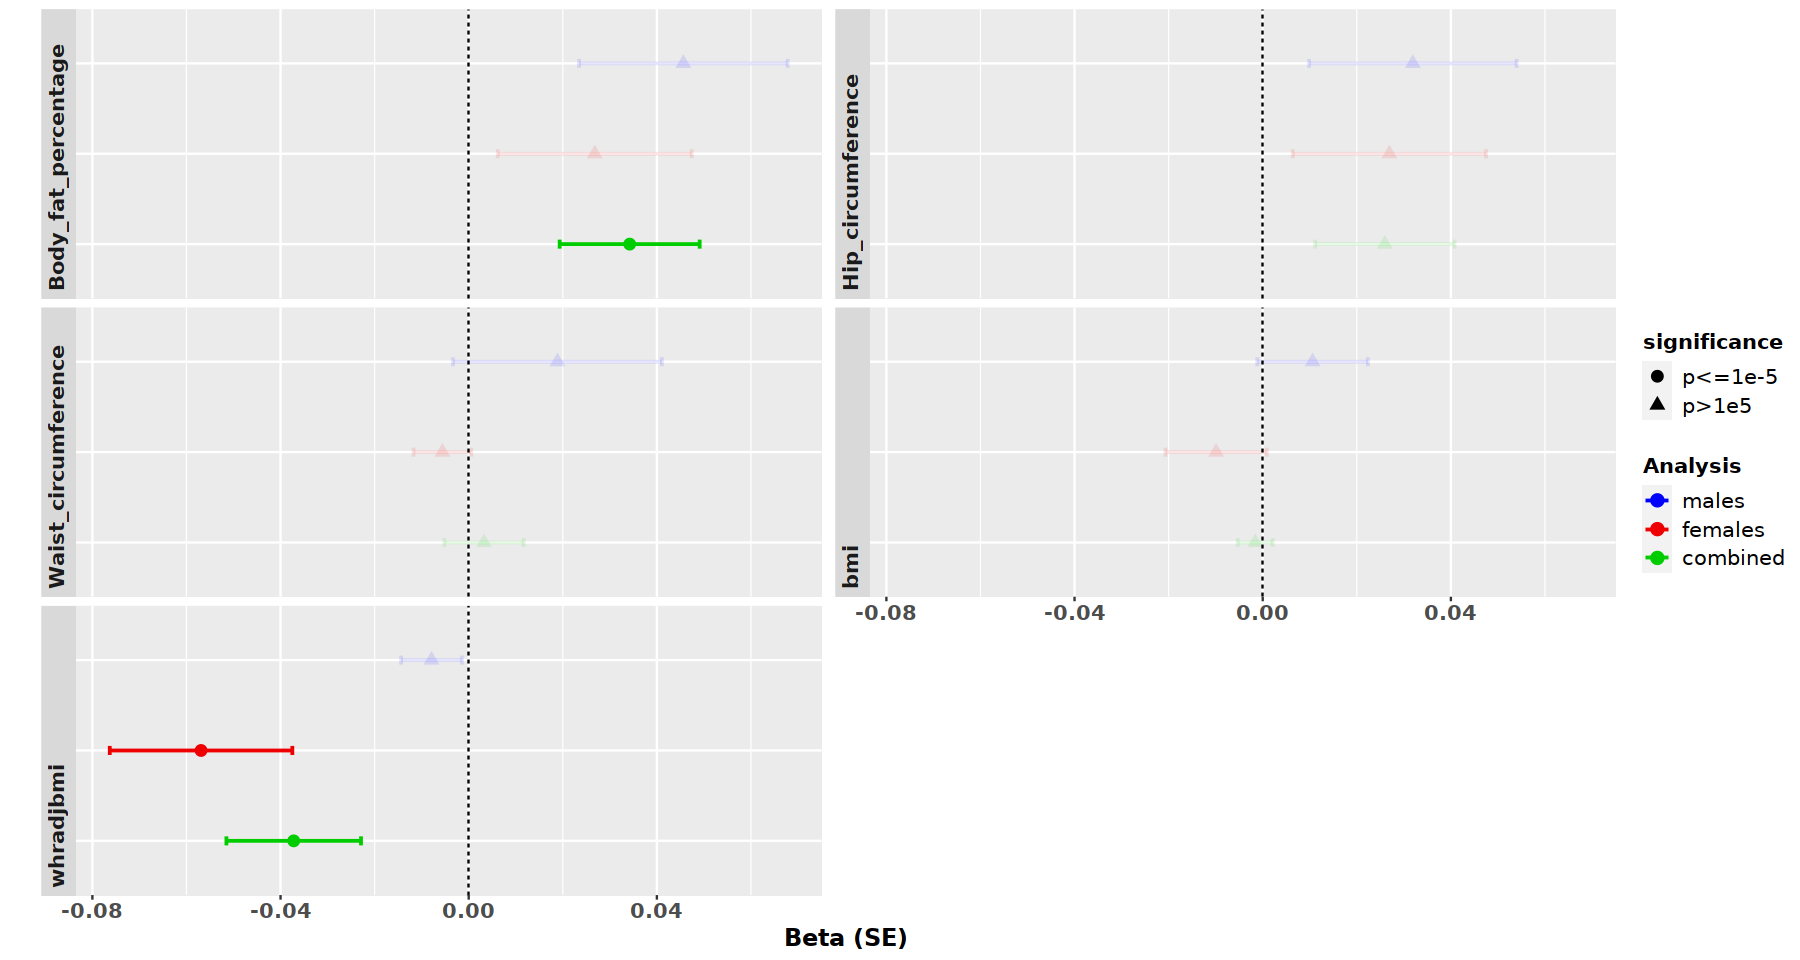

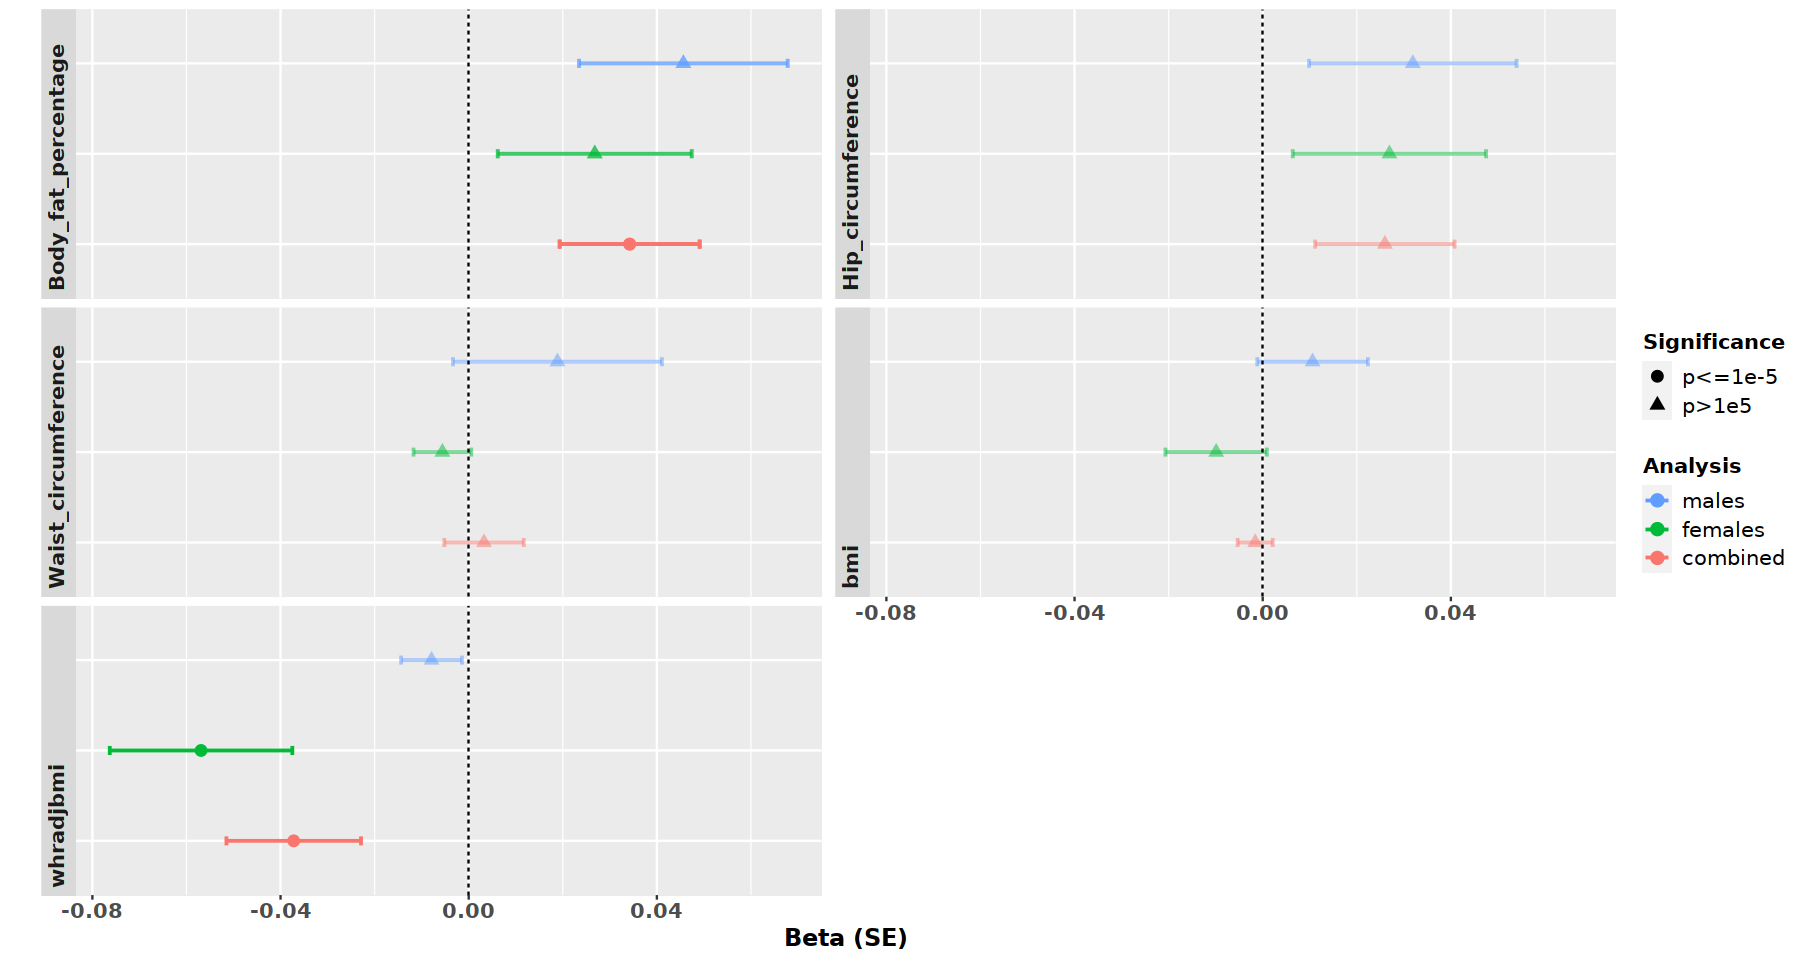

In [63]:
g = 'ANGPTL4'
n= which(data_all$Gene == g)
data = data_all[n,]



#data$shape = ifelse(data$P<=1e-5, 17, 16)


n = which(data$Trait %in% c("bmix", "whradjbmi", "Waist_circumference", "Hip_circumference", "Body_fat_percentage"))
Significance = data$Significance[n]


ggplot(data=data[n,],
                aes(x = Analysis,y = Beta_MinorAllele, ymin = LCI, ymax = UCI, 
                    shape=Significance, color = Analysis))+
    geom_point(size = 3, alpha = data$transparency[n]) + 
    geom_errorbar(width=0.1, cex=0.8, alpha = data$transparency[n])+ ### SE
    geom_hline(yintercept=0, linetype=2)+
    facet_wrap(~Trait,strip.position="left",ncol=2,scales = "free_y") +
    theme(plot.title=element_text(size=10,face="bold"),
            axis.text.y=element_blank(),
            axis.ticks.y=element_blank(),
            axis.text.x=element_text(face="bold", size=12),
            axis.title=element_text(size=14,face="bold"),
            strip.text.y = element_text(hjust=0,vjust = 1,face="bold",size=12))+
    coord_flip()+
    xlab('')+ ylab("Beta (SE)") +
    guides(col = guide_legend(reverse = TRUE))+
    theme(legend.text=element_text(size=12),legend.title=element_text(size=12,face="bold"))

 

In [64]:
library(ggplot2)
data_all = read.table("/well/lindgren-ukbb/projects/ukbb-11867/ferreira/PCOS/locuszoom_plots/All_leads_stats_nowindow_2.txt", header=T)


for(g in c("ANGPTL4", "ANGPTL3", "ANGPTL8", "APOC3", "PCSK9"))
{
   n= which(data_all$Gene == g)
	data = data_all[n,]

	data$pheno = paste(data$Trait, "-", data$Analysis, sep="")
	data$LCI = data$Beta_MinorAllele - 1.96 * data$SE
	data$UCI = data$Beta_MinorAllele + 1.96 * data$SE

	#data$shape = ifelse(data$P<=1e-5, 17, 16)
	data$shape = ifelse(data$P<=1e-5, "p<=1e-5", "p>1e5")
	data$Significance = factor(data$shape)
	data$transparency = ifelse(data$P<=1e-5, 1, 0.5)

	n = which(data$Trait %in% c("bmi", "whradjbmi", "Waist_circumference", "Hip_circumference", "Body_fat_percentage"))
	Significance = data$Significance[n]


	p2 = ggplot(data=data[n,],
	                aes(x = Analysis,y = Beta_MinorAllele, ymin = LCI, ymax = UCI, 
	                    shape=Significance, color = Analysis))+
	    geom_point(size = 3, alpha = data$transparency[n]) + 
	    geom_errorbar(width=0.1, cex=0.8, alpha = data$transparency[n])+ ### SE
	    geom_hline(yintercept=0, linetype=2)+
	    facet_wrap(~Trait,strip.position="left",ncol=2,scales = "free_y") +
	    theme(plot.title=element_text(size=10,face="bold"),
	            axis.text.y=element_blank(),
	            axis.ticks.y=element_blank(),
	            axis.text.x=element_text(face="bold", size=12),
	            axis.title=element_text(size=14,face="bold"),
	            strip.text.y = element_text(hjust=0,vjust = 1,face="bold",size=12))+
	    coord_flip()+
	    xlab('')+ ylab("Beta (SE)") +
	    guides(col = guide_legend(reverse = TRUE))+
	    theme(legend.text=element_text(size=12),legend.title=element_text(size=12,face="bold"))


	outfile = paste("/well/lindgren-ukbb/projects/ukbb-11867/ferreira/PCOS/ANGPTLs/", g, "_forest_plots_1.png", sep="")
    ggsave(outfile, p2, width = 12, height = 8)
    
}

In [65]:
?ggsave

Warning message in seq_len(head.end.idx):
"first element used of 'length.out' argument"
ERROR while rich displaying an object: Error in seq_len(head.end.idx): argument must be coercible to non-negative integer

Traceback:
1. FUN(X[[i]], ...)
2. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
3. tryCatchList(expr, classes, parentenv, handlers)
4. tryCatchOne(expr, names, parentenv, handlers[[1L]])
5. doTryCatch(return(expr), name, parentenv, handler)
6. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_conte